<a href="https://colab.research.google.com/github/sv9-ru/25-koptyaev-TimeSeriesCourse/blob/main/06_Chains(DO1_2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 6. Поиск эволюционирующих шаблонов с помощью матричного профиля ряда.**

In [1]:
#%load_ext autoreload
#%autoreload 2

import os
from google.colab import drive
drive.mount('/content/drive')
practice_dir_path = '/content/drive/My Drive/MASHINKA/06 Chains'
os.chdir(practice_dir_path)

Mounted at /content/drive


## **Часть 1.** Поиск цепочек временного ряда.

Импорт библиотек и модулей

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import stumpy
from sklearn.metrics import mean_squared_error

В первом задании вам предстоит выполнить поиск эволюционирующих шаблонов временного ряда. Выполните считывание набора данных [Rotation Matrix](datasets/Rotation%20Matrix.txt), найдите в нем самую длинную цепочку и выведите индексы начала звеньев этой цепочки.

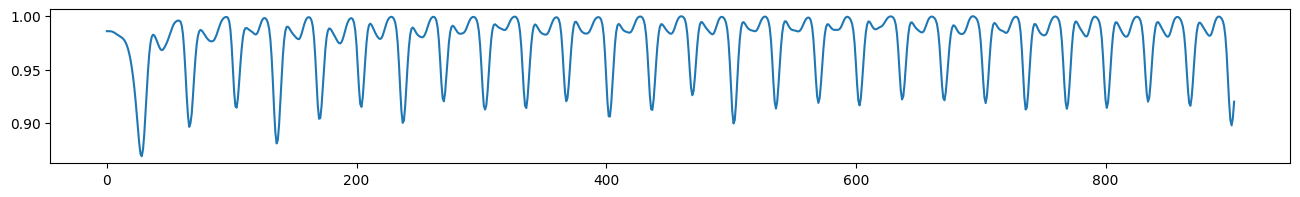

In [3]:
fig, ax = plt.subplots(figsize=(16, 2))
ts = np.loadtxt('datasets/Rotation Matrix.txt')
ax.plot(ts)

In [4]:
m = 50
mp = stumpy.stump(ts, m=m)

In [5]:
print(mp[:,0])

[2.7408223578420863 2.6745163377709207 2.639759265328178
 2.6135107003036326 2.5887831951389426 2.566390311098335
 2.5547787496875087 2.578161556702486 2.7002411857979154 2.782019914084923
 2.7001562272676662 2.6783169230466797 2.7640494691675697
 2.978100647743232 3.2264534518168646 3.337956412154962 3.29542693183127
 3.210120361903816 3.1692317152305534 3.181826188637143 3.1347235626488557
 3.0122043520961914 2.795649803640661 2.4612692481541463 2.032146715773424
 1.6105377397146476 1.297217631335755 1.1686079740885684
 1.1847636332159504 1.2783336988627416 1.3916433679785607
 1.4999309258527305 1.5775231760810597 1.615277709642834 1.58535069576553
 1.4934046012897226 1.473630387493569 1.5115082108329663
 1.4507396372363828 1.4599929528970186 1.4666259290484336
 1.434507544549282 1.3779017082906497 1.2807527211304448
 1.2038001777608542 1.167096654850107 1.1152015769616377
 1.2685292260273486 1.7686081141970356 2.259637146314766
 2.6783169230466797 2.7640494691675697 2.97810064774323

In [6]:
all_chain_set, unanchored_chain = stumpy.allc(mp[:, 2], mp[:, 3])

In [7]:
unanchored_chain

array([ 16,  55, 124, 490, 524, 591])

In [8]:
ts[unanchored_chain]

array([0.97281057, 0.9946453 , 0.9952884 , 0.99623   , 0.99572587,
       0.9973732 ])

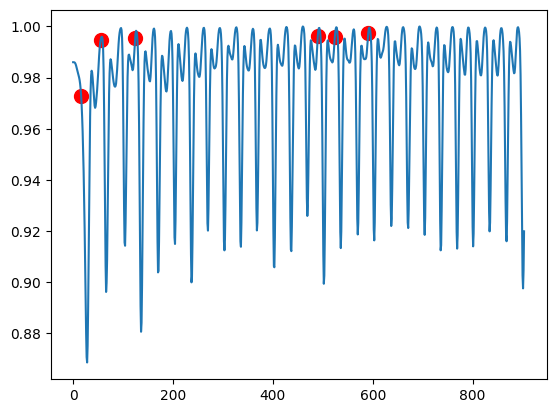

In [13]:
plt.plot(ts)
plt.scatter(unanchored_chain, ts[unanchored_chain], c="r", s=100)

In [14]:
print(unanchored_chain)

[ 16  55 124 490 524 591]


❓ Проанализируйте и изложите содержательный смысл полученных результатов.

Нашли точки про помощи библиотеки stumpy chains. Нашли в нем самую длинную цепочку и вывели индексы начала звеньев этой цепочки.

## **Часть 2. Визуализация цепочек**

Выполните визуализацию найденных в прошлом задании цепочек: постройте график временного ряда, на котором выделены звенья цепочек. Также постройте график, на котором изображены только сами звенья.

In [15]:
df = pd.DataFrame(ts, columns=["ts"])

In [16]:
df

,ts
0,0.985997
1,0.985993
2,0.985966
3,0.985876
4,0.985650
...,...
899,0.919441
900,0.902661
901,0.897607
902,0.904541


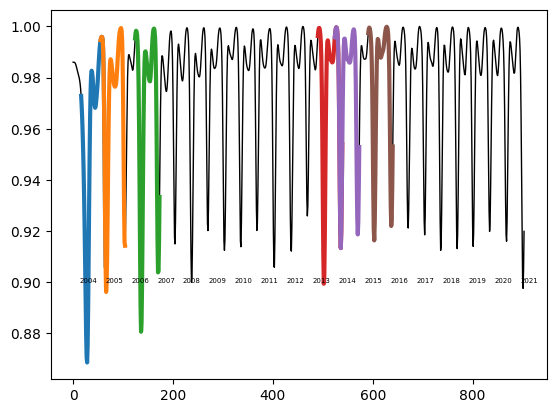

In [23]:
plt.plot(df['ts'], linewidth=1, color='black')
for i in range(unanchored_chain.shape[0]):
    y = df['ts'].iloc[unanchored_chain[i]:unanchored_chain[i]+m]
    x = y.index.values
    plt.plot(x, y, linewidth=3)
for i, x in enumerate(range(0, df.shape[0], 52)):
    plt.text(x+12, 0.9, str(2004+i), color="black", fontsize=5)

plt.show()

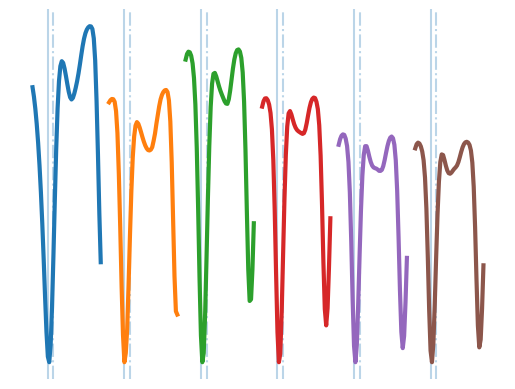

In [25]:
plt.axis('off')
for i in range(unanchored_chain.shape[0]):
    data = df['ts'].iloc[unanchored_chain[i]:unanchored_chain[i]+m].reset_index().values
    x = data[:, 0]
    y = data[:, 1]
    plt.axvline(x=x[0]-x.min()+(m+5)*i + 11, alpha=0.3)
    plt.axvline(x=x[0]-x.min()+(m+5)*i + 15, alpha=0.3, linestyle='-.')
    plt.plot(x-x.min()+(m+5)*i, y-y.min(), linewidth=3)
plt.show()

❓ Проанализируйте и изложите содержательный смысл полученных результатов.

## **Часть 3.** Предсказывание значений ряда на основе цепочек.

Предскажите значения последнего звена цепочки, вычислив разность между двумя предыдущими звеньями цепочки. Сравните полученное предсказание с истинным значением.

In [ ]:
# INSERT YOUR CODE

❓ Проанализируйте и изложите содержательный смысл полученных результатов.